# 📐 Descriptive Statistics & Data Dispersion Foundations

**Course**: Machine Learning Mathematics — Lecture Notes
**Topic**: Measures of Central Tendency, Dispersion Metrics, Covariance, Pearson Correlation, and Distribution Visualizations

## 1. Measures of Central Tendency: Mean & Median

### Intuition First
Central tendency metrics identify the central or typical value of a data distribution. The arithmetic mean represents the balance center of the dataset, while the median provides a robust midpoint that resists extreme skewness or outlier values.

### Formal Definition / Math
For a dataset $X = \{x_1, x_2, \dots, x_N\}$:

- **Arithmetic Mean**:

$$\begin{equation}
\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i
\end{equation}$$

- **Median**: For ordered elements $x_{(1)} \le x_{(2)} \le \dots \le x_{(N)}$:

$$\begin{equation}
\text{Median}(X) = \begin{cases} x_{\left(\frac{N+1}{2}\right)} & \text{if } N \text{ is odd} \\ \frac{x_{\left(\frac{N}{2}\right)} + x_{\left(\frac{N}{2}+1\right)}}{2} & \text{if } N \text{ is even} \end{cases}
\end{equation}$$

### Connection to the Code
- `np.mean(x)`: Computes arithmetic mean $\bar{x}$.
- `np.median(x)`: Computes exact median for odd ($N=7 \implies x_{(4)}=10$) and even ($N=6 \implies \frac{9+11}{2}=10.0$) length samples.

**Key Takeaway**: **The mean captures the global average, while the median provides a robust measure of center that is unaffected by extreme outliers.**

In [2]:
import numpy as np

x = [1, 4, 5, 4, 8]
print(np.mean(x))

4.4


In [3]:
x = [5, 8, 10, 10, 15, 18, 23]
print(np.median(x))

10.0


In [4]:
x = [4, 7, 9, 11, 12, 20]
print(np.median(x))

10.0


## 2. Most Frequent Observation: The Mode

### Intuition First
The mode is the most frequently occurring value in a discrete distribution or categorical feature. In multi-modal distributions, identifying modes highlights distinct clusters or sub-populations.

### Formal Definition / Math
The mode is defined as the value maximizing the empirical frequency function:

$$\begin{equation}
\text{Mode}(X) = \arg\max_{v} \sum_{i=1}^{N} \mathbb{I}(x_i = v)
\end{equation}$$

### Connection to the Code
- `scipy.stats.mode(x)`: Returns a `ModeResult` containing the modal value (`m[0]` or `m.mode`) and its frequency count (`m[1]` or `m.count`).

**Key Takeaway**: **The mode identifies peak frequency categories and discrete distribution clusters.**

In [5]:
import scipy
from scipy import stats

In [6]:
x = [1, 2, 3, 4, 4, 5, 6, 6, 6]
m = scipy.stats.mode(x)
print(m)

ModeResult(mode=np.int64(6), count=np.int64(3))


In [7]:
m[1]

np.int64(3)

## 3. Percentiles, Interquartile Range (IQR), and Outlier Detection

### Intuition First
Percentiles partition ordered data into 100 equal parts. The Interquartile Range ($\text{IQR} = Q_3 - Q_1$) measures the spread of the middle 50% of observations. Tukey's fences use $1.5 \times \text{IQR}$ bounds to systematically detect and filter statistical anomalies and outliers.

### Formal Definition / Math
For quartiles $Q_1$ ($25^{\text{th}}$ percentile), $Q_2$ (median, $50^{\text{th}}$ percentile), and $Q_3$ ($75^{\text{th}}$ percentile):

$$\begin{equation}
\text{IQR} = Q_3 - Q_1
\end{equation}$$

Tukey's Outlier Fences:

$$\begin{aligned}
\text{Lower Fence} &= Q_1 - 1.5 \times \text{IQR} \\
\text{Upper Fence} &= Q_3 + 1.5 \times \text{IQR}
\end{aligned}$$

An observation $x_i$ is classified as an outlier if $x_i < \text{Lower Fence}$ or $x_i > \text{Upper Fence}$.

### Connection to the Code
- `np.percentile(a, [25, 50, 75])`: Evaluates quartiles $Q_1 = 19.0$, $Q_2 = 22.0$, $Q_3 = 23.5$.
- `IQR = Q3 - Q1`: Yields the interquartile range spread.
- `outliers = a[(a < 14.75) | (a > 28.75)]`: Filters anomalous data points lying beyond the fences.

**Key Takeaway**: **Tukey's IQR method establishes non-parametric outlier boundaries resistant to extreme data skew.**

In [8]:
a = np.array([5, 7, 10, 15, 19, 21, 21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 24, 25])

In [9]:
q = np.percentile(a, [25, 50, 75])
print(q)

[20.  23.  23.5]


In [10]:
Q1 = q[0]
Q3 = q[2]

In [11]:
IQR = Q3 - Q1
IQR

np.float64(3.5)

In [12]:
Q1 - 1.5 * IQR

np.float64(14.75)

In [13]:
Q3 + 1.5 * IQR

np.float64(28.75)

In [14]:
outliers = a[(a < 14.75) | (a > 28.75)]
outliers

array([ 5,  7, 10])

## 4. Measures of Dispersion: Variance & Standard Deviation

### Intuition First
Variance and standard deviation quantify the degree of spread or dispersion of data points around their arithmetic mean $\bar{x}$. Standard deviation is expressed in the original units of measurement, making it intuitive for error analysis and Gaussian confidence intervals.

### Formal Definition / Math
For population size $N$:

- **Population Variance**:

$$\begin{equation}
\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2
\end{equation}$$

- **Population Standard Deviation**:

$$\begin{equation}
\sigma = \sqrt{\sigma^2} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2}
\end{equation}$$

*(Note: For vector norm interpretation of squared deviations, see [1.Vector.ipynb](1.Vector.ipynb).)*

### Connection to the Code
- `np.var(x)`: Computes population variance $\sigma^2$.
- `sum([(x_i - xbar) ** 2 for x_i in x]) / len(x)`: Explicit step-by-step arithmetic verification.
- `sigma = np.std(x)`: Evaluates standard deviation $\sigma = \sqrt{\sigma^2}$.

**Key Takeaway**: **Variance measures average squared deviation, while standard deviation restores the original scale of the feature.**

In [15]:
x = [1, 4, 5, 4, 8]
np.var(x)

np.float64(5.04)

In [ ]:
xbar = np.mean(x)
sd = [(x_i - xbar) ** 2 for x_i in x]
sum(sd) / len(x)

np.float64(5.04)

In [17]:
sigma = np.std(x)
sigma

np.float64(2.244994432064365)

## 5. Bivariate Association: Covariance & Degrees of Freedom

### Intuition First
Covariance measures the joint variability and directional linear relationship between two continuous variables $X$ and $Y$. A positive covariance indicates that both variables tend to increase together, while a negative covariance indicates an inverse relationship.

### Formal Definition / Math
For paired samples $(x_i, y_i)_{i=1}^N$:

$$\begin{equation}
\text{Cov}(X, Y) = \sigma_{XY} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})
\end{equation}$$

The $2 \times 2$ covariance matrix is:

$$\begin{equation}
\Sigma = \begin{bmatrix} \text{Var}(X) & \text{Cov}(X, Y) \\ \text{Cov}(Y, X) & \text{Var}(Y) \end{bmatrix}
\end{equation}$$

### Connection to the Code
- `cov = sum([(x[i] - xbar) * (y[i] - ybar) for i in range(n)]) / n`: Manual sum-of-products implementation.
- `np.cov(x, y, ddof=0)`: Computes population covariance matrix with divisor $N$ (`ddof=0`).
- `np.cov(a, b, ddof=0)[0][1]`: Evaluates negative covariance ($-17.5$) for inverse linear relationship $b = 100 - 7a$.

**Key Takeaway**: **Covariance indicates the direction of linear association between features, forming the basis for covariance matrices in PCA.**

In [ ]:
x = [1, 2, 3]
y = [12, 14, 16]
n = len(x)

In [21]:
xbar = np.mean(x)
ybar = np.mean(y)
print(xbar)
print(ybar)

2.0
14.0


In [ ]:
p = []
for i in range(n):
    p.append((x[i] - xbar) * (y[i] - ybar))
print(p)
cov = sum(p) / n
cov

[np.float64(2.0), np.float64(0.0), np.float64(2.0)]


np.float64(1.3333333333333333)

In [27]:
print(np.var(x))
print(np.var(y))

0.6666666666666666
2.6666666666666665


In [ ]:
cov = np.cov(x, y, ddof=0)
cov

array([[0.66666667, 1.33333333],
       [1.33333333, 2.66666667]])

In [29]:
cov[0][1]

np.float64(1.3333333333333333)

In [ ]:
a = [1, 2, 3, 4]
b = [93, 86, 79, 72]  # b = 100-7a
np.cov(a, b, ddof=0)[0][1]

np.float64(-8.75)

## 6. Standardized Linear Correlation: Pearson Correlation Coefficient ($r$)

### Intuition First
Covariance is scale-dependent, making it difficult to assess relationship strength across variables with different units. The **Pearson Correlation Coefficient ($r$)** normalizes covariance by the product of individual standard deviations, bounding the metric strictly within $[-1, 1]$.

### Formal Definition / Math
The Pearson correlation coefficient is:

$$\begin{equation}
r_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} = \frac{\sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{N} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{N} (y_i - \bar{y})^2}}
\end{equation}$$

- $r = +1.0$: Perfect positive linear correlation ($y = 2x + 10$).
- $r = -1.0$: Perfect negative linear correlation ($y = 100 - 7x$).
- $r = 0.0$: No linear relationship.

### Connection to the Code
- `p = cov / (sx * sy)`: Manual normalization of covariance by standard deviations.
- `scipy.stats.pearsonr(x, y)`: Computes exact Pearson correlation coefficient $r$ and two-tailed p-value.

**Key Takeaway**: **Pearson's $r$ provides a dimensionless metric $\in [-1, 1]$ measuring the strength and direction of linear dependence.**

In [ ]:
x = [1, 2, 3]
y = [12, 14, 16]  # y = 2x + 10

In [ ]:
sx = np.var(x) ** (1 / 2)
sy = np.var(y) ** (1 / 2)

cov = np.cov(x, y, ddof=0)[0][1]
p = cov / (sx * sy)
p

np.float64(1.0)

In [ ]:
r, p = scipy.stats.pearsonr(x, y)
r

np.float64(0.9999999999999998)

In [ ]:
x = [1, 2, 3]
y = [93, 86, 79]  # y = 100-7x
r, p = scipy.stats.pearsonr(x, y)
r

np.float64(-1.0)

## 7. Statistical Visualizations: Box-and-Whisker Plots & Histograms

### Intuition First
Graphical summaries reveal distribution shape, symmetry, spread, and outlier locations at a glance. Boxplots display the five-number summary ($[\text{Min}, Q_1, Q_2, Q_3, \text{Max}]$) and outliers, while histograms approximate the underlying probability density function through empirical bin frequencies.

### Connection to the Code
- `plt.boxplot(a)` & `sns.boxplot(x=a, width=0.3)`: Renders box-and-whisker diagrams with median line, interquartile box, and whisker fences.
- `plt.hist(x, bins=6, color='blue', edgecolor='black')`: Bins continuous observations to visualize empirical frequency distributions.

**Key Takeaway**: **Boxplots and histograms provide complementary visual tools for detecting distribution skewness and anomaly patterns.**

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
a = np.array([5, 7, 10, 15, 19, 21, 21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 24, 25])

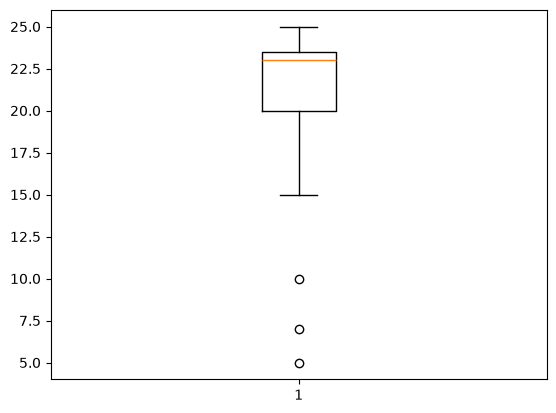

In [40]:
plt.boxplot(a)
plt.show()

<Axes: >

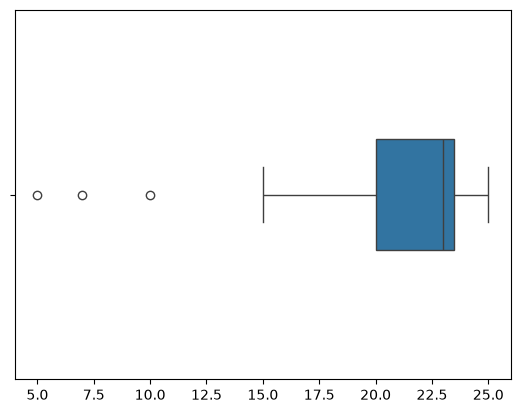

In [41]:
sns.boxplot(x=a, width=0.3)

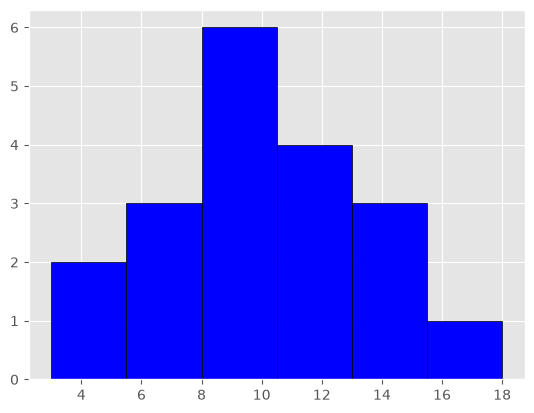

In [ ]:
x = [3, 4, 6, 7, 7, 8, 9, 9, 10, 10, 10, 11, 12, 12, 12, 15, 15, 15, 18]
plt.style.use("ggplot")
plt.hist(x, bins=6, color="blue", edgecolor="black")
plt.show()